# 03 · CNN baseline

Builds the from-scratch CNN, inspects it layer by layer, and looks at the
training curves the real run produced.


In [1]:
# Make the project's own modules importable, and apply the OpenMP fix that must
# run before torch is imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
sys.path.insert(0, str(PROJECT_ROOT / "training"))

import app.core.runtime  # noqa: F401  (sets OMP env before numpy/torch)

import json
import numpy as np
import matplotlib.pyplot as plt

from app.core.config import settings

print("Project root:", PROJECT_ROOT)


Project root: D:\Data science projects\Plant disease detection


## Building the model

In [2]:
import torch
from app.ml.architectures import build_model, count_parameters, model_size_mb

split_config = json.loads(settings.splits_path.read_text(encoding="utf-8"))
num_classes = split_config["num_classes"]

model = build_model("cnn_baseline", num_classes, pretrained=False)
total, trainable = count_parameters(model)
print(f"Classes    : {num_classes}")
print(f"Parameters : {total:,} ({trainable:,} trainable)")
print(f"Size       : {model_size_mb(model):.2f} MB")
print(model)


Classes    : 38
Parameters : 1,248,774 (1,248,774 trainable)
Size       : 4.77 MB
PlantCNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (attention): Identity()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (

## How the spatial dimensions shrink

Each stage halves the resolution and doubles the channels.

In [3]:
x = torch.randn(1, 3, 224, 224)
print(f"{'stage':<8}{'output shape':<24}{'elements':>12}")
print("-" * 46)
print(f"{'input':<8}{str(tuple(x.shape)):<24}{x.numel():>12,}")
with torch.no_grad():
    for index, block in enumerate(model.features):
        x = block(x)
        print(f"{index:<8}{str(tuple(x.shape)):<24}{x.numel():>12,}")


stage   output shape                elements
----------------------------------------------
input   (1, 3, 224, 224)             150,528
0       (1, 32, 112, 112)            401,408
1       (1, 64, 56, 56)              200,704
2       (1, 128, 28, 28)             100,352
3       (1, 256, 14, 14)              50,176


## Augmentation, visualised

The same transform the trainer uses. Every variant must still be a plausible photograph of a leaf.

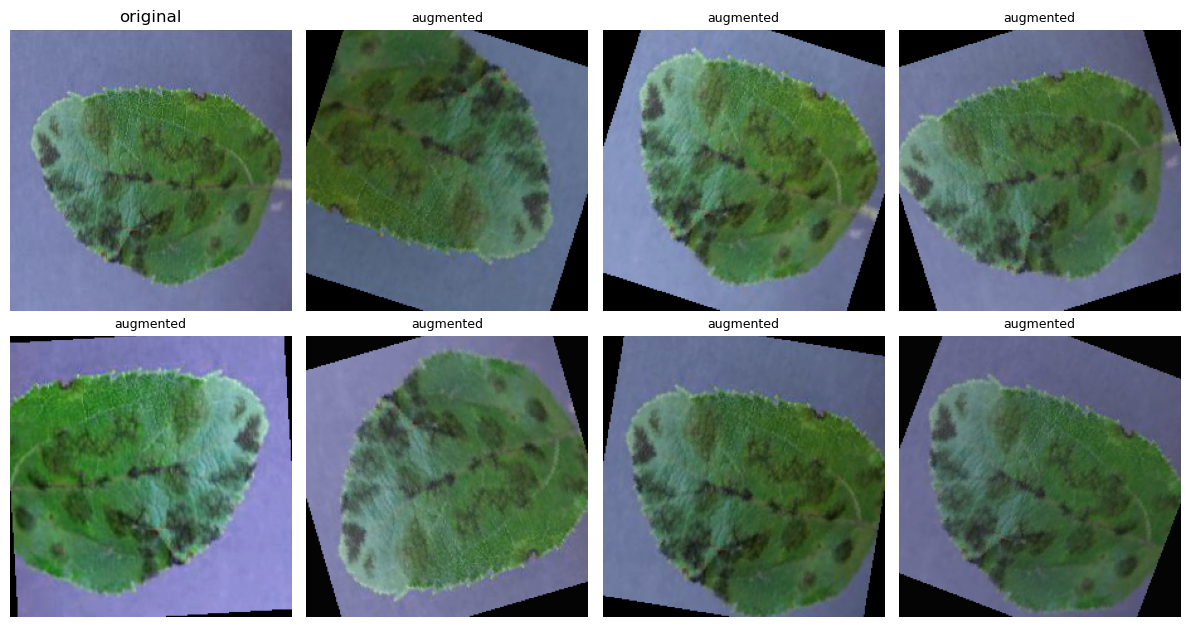

In [4]:
from PIL import Image
from app.ml.datasets import read_manifest
from app.ml.transforms import build_train_transform, denormalize

rows = read_manifest(settings.data_dir / "manifests" / "train.csv")
with Image.open(rows[0].path) as handle:
    original = handle.convert("RGB")

transform = build_train_transform(224, strength="medium")
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
axes[0, 0].imshow(original); axes[0, 0].set_title("original"); axes[0, 0].axis("off")
for ax in axes.ravel()[1:]:
    tensor = transform(original).unsqueeze(0)
    ax.imshow(denormalize(tensor)[0].permute(1, 2, 0).numpy())
    ax.set_title("augmented", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()


## Training curves from the real run

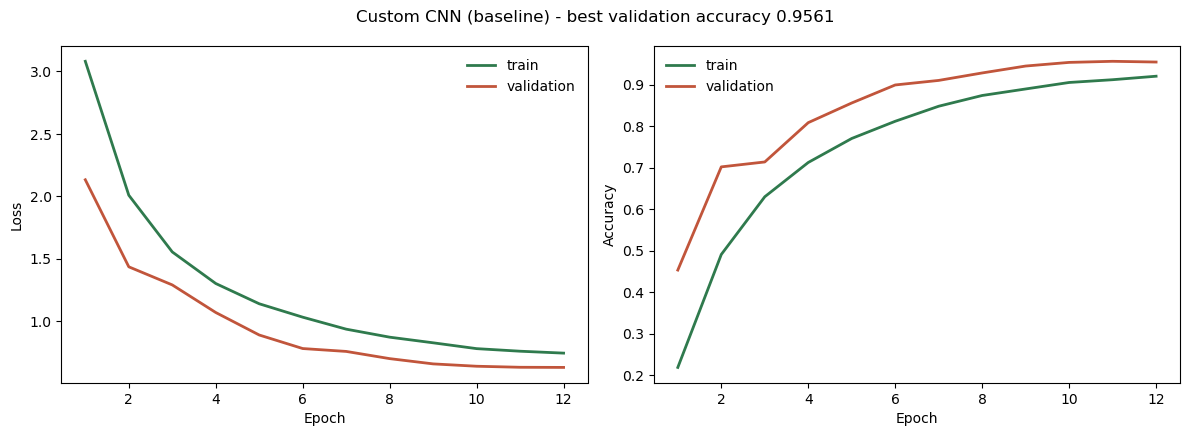

Test accuracy 0.9583   macro F1 0.9578   top-3 0.9950


In [5]:
ledger = json.loads((settings.results_dir / "experiments.json").read_text(encoding="utf-8"))
record = next((r for r in ledger if r["model_name"] == "cnn_baseline"), None)

if record:
    history = record["history"]
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4.4))
    ax_loss.plot(history["epoch"], history["train_loss"], label="train", color="#2f7a4d", lw=2)
    ax_loss.plot(history["epoch"], history["val_loss"], label="validation", color="#c1553b", lw=2)
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss"); ax_loss.legend(frameon=False)
    ax_acc.plot(history["epoch"], history["train_acc"], label="train", color="#2f7a4d", lw=2)
    ax_acc.plot(history["epoch"], history["val_acc"], label="validation", color="#c1553b", lw=2)
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy"); ax_acc.legend(frameon=False)
    fig.suptitle(f"{record['label']} - best validation accuracy {record['best_val_accuracy']:.4f}")
    plt.tight_layout(); plt.show()

    metrics = record["test"]["metrics"]
    print(f"Test accuracy {metrics['accuracy']:.4f}   macro F1 {metrics['f1_macro']:.4f}   "
          f"top-3 {metrics['top3_accuracy']:.4f}")
else:
    print("Run `python training/run_experiments.py --suite benchmark` first.")
